In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("data/processed/Superstore_Clean.csv")

In [9]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.dtypes

row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub_category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

In [14]:
df[["order_date", "ship_date"]].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [40]:
# =========================================
# Feature Engineering - Date features
# =========================================

# Year
df["order_year"] = df["order_date"].dt.year

# Month number
df["order_month"] = df["order_date"].dt.month

# month Name
df["order_month_name"] = df["order_date"].dt.month_name()

# Quarter
df["order_quarter"] = df["order_date"].dt.quarter

# Day
df["order_day"] = df["order_date"].dt.day

# Weekday Name
df["order_weekday"] = df["order_date"].dt.day_name()

In [17]:
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [18]:
df["profit_margin"] = (df["profit"] / df["sales"]) * 100

In [20]:
df[
    [
        "order_date",
        "order_year",
        "order_month",
        "order_month_name",
        "order_quarter",
        "order_weekday",
        "shipping_days",
        "profit_margin"
    ]
].head()

,order_date,order_year,order_month,order_month_name,order_quarter,order_weekday,shipping_days,profit_margin
0,2016-08-11,2016,8,August,3,Thursday,92,16.00
1,2016-08-11,2016,8,August,3,Thursday,92,30.00
2,2016-12-06,2016,12,December,4,Tuesday,-173,47.00
3,2015-11-10,2015,11,November,4,Tuesday,-23,-40.00
4,2015-11-10,2015,11,November,4,Tuesday,-23,11.25


In [21]:
print(df["shipping_days"].max())

214


In [27]:
# Total Sales
total_sales = df["sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [28]:
# Total Profit
total_profit = df["profit"].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [29]:
# Total Orders
total_orders = df["order_id"].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 5,009


In [30]:
# Total Customers
total_customers = df["customer_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 793


In [32]:
# Average Order Value
average_order_value = total_sales / total_orders
print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $458.61


In [33]:
# Overall Profit Margin
profit_margin = (total_profit / total_sales) * 100
print(f"Overall Profit Margin: {profit_margin:,.2f}")

Overall Profit Margin: 12.47


In [39]:
kpi_summary = pd.DataFrame({
    "KPI":[
        "Total Sales",
        "Total Profit",
        "Total Order",
        "Total Customers",
        "Average Order Value",
        "Profit Margin (%)"
    ],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        f"${total_orders:,}",
        f"{total_customers:,}",
        f"{average_order_value:,.2f}",
        f"{profit_margin:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Total Order,"$5,009"
3,Total Customers,793
4,Average Order Value,458.61
5,Profit Margin (%),12.47%


In [41]:
# ====================
# Sales by category
# ====================

sales_by_category = (
    df.groupby("category", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales",ascending=False)
)

sales_by_category

,category,sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


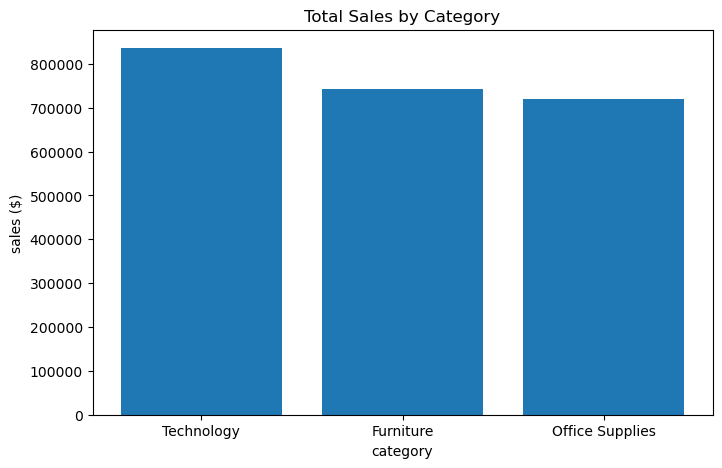

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_by_category["category"],
    sales_by_category["sales"]
)

plt.title("Total Sales by Category")
plt.xlabel("category")
plt.ylabel("sales ($)")
plt.show()

### Business Insight

Technology generated the highest revenue, indicating strong customer demand for technology products.

Office Supplies generated the lowest revenue, suggesting an opportunity to evaluate product assortment, pricing, or marketing efforts.

In [43]:
# ========================
# Sales by Sub-Category
# ========================

sales_by_subcategory = (
    df.groupby("sub_category", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
)

sales_by_subcategory

,sub_category,sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


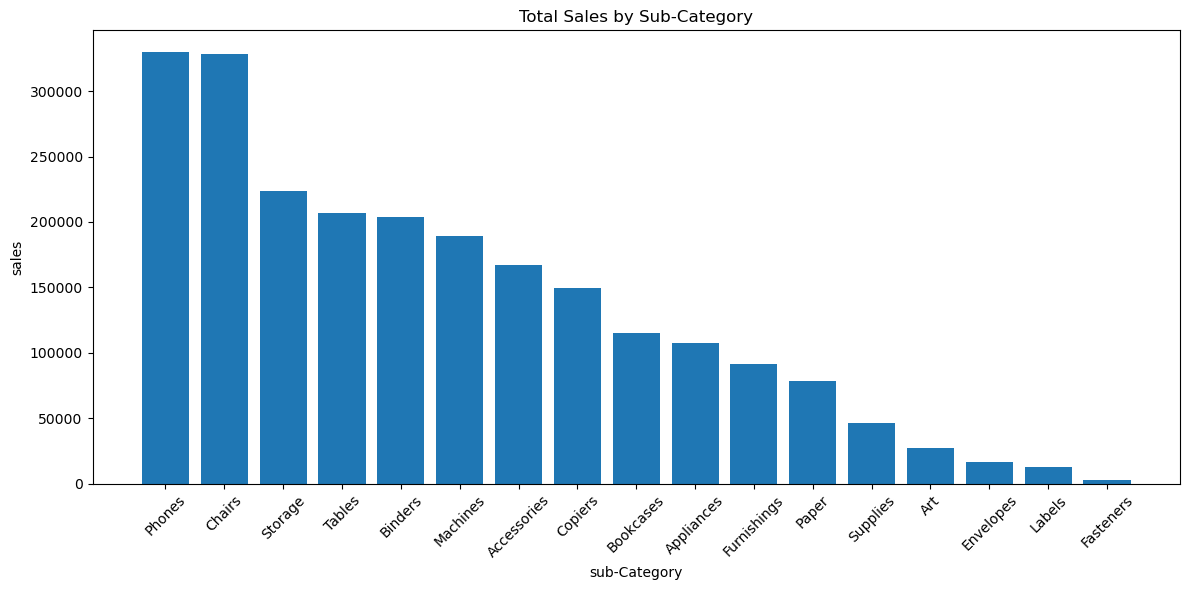

In [45]:
plt.figure(figsize=(12,6))

plt.bar(
    sales_by_subcategory["sub_category"],
    sales_by_subcategory["sales"]
)

plt.title("Total Sales by Sub-Category")
plt.xlabel("sub-Category")
plt.ylabel("sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

- Identify the top-performing sub-category.
- Identify the lowest-performing sub-category.
- Recommend focusing inventory and promotions on high-performing sub-categories while reviewing the strategy for low-performing ones.

In [46]:
sales_by_region = (
    df.groupby("region", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales",ascending=False)
)

sales_by_region

,region,sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


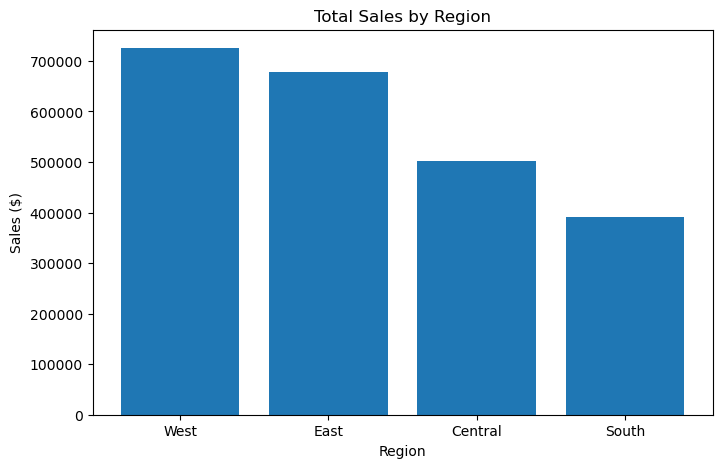

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_by_region["region"],
    sales_by_region["sales"]
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")

plt.show()

### Business Insight

Compare regional sales performance to identify the strongest and weakest markets.

Regions with lower sales may require additional marketing, pricing adjustments, or expansion strategies.

In [48]:
top_states = (
    df.groupby("state",as_index=False)["sales"]
    .sum()
    .sort_values(by="sales",ascending=False)
    .head(10)
)

top_states

,state,sales
3,California,457687.6315
30,New York,310876.2710
41,Texas,170188.0458
45,Washington,138641.2700
36,Pennsylvania,116511.9140
8,Florida,89473.7080
11,Illinois,80166.1010
33,Ohio,78258.1360
20,Michigan,76269.6140
44,Virginia,70636.7200


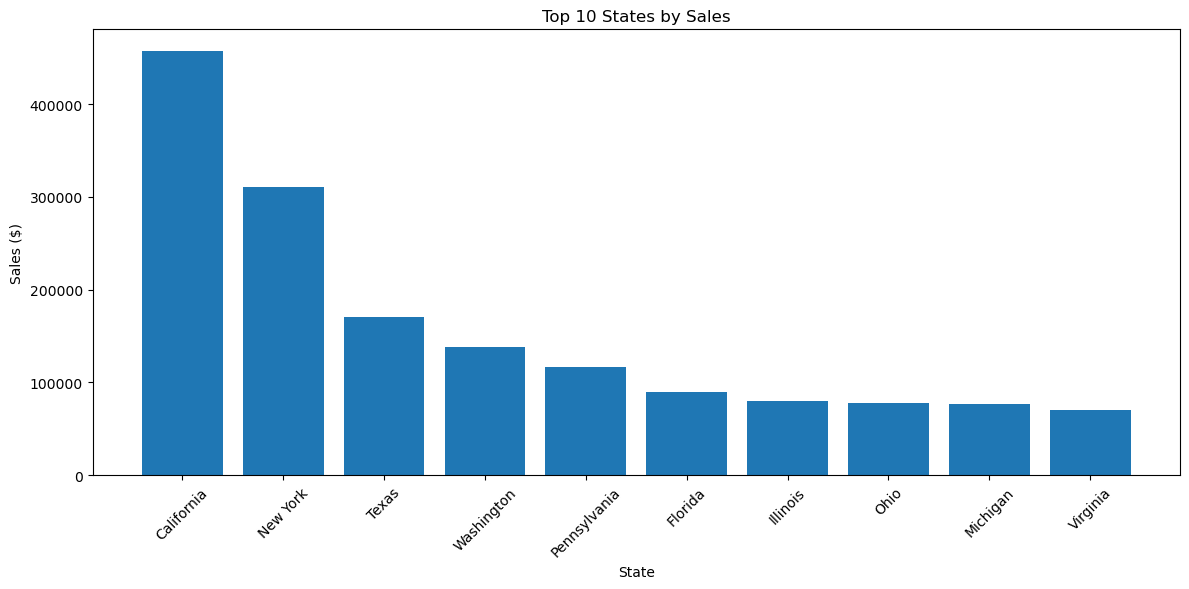

In [49]:
plt.figure(figsize=(12,6))

plt.bar(
    top_states["state"],
    top_states["sales"]
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
sales_by_segment = (
    df.groupby("segment", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
)

sales_by_segment

,segment,sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


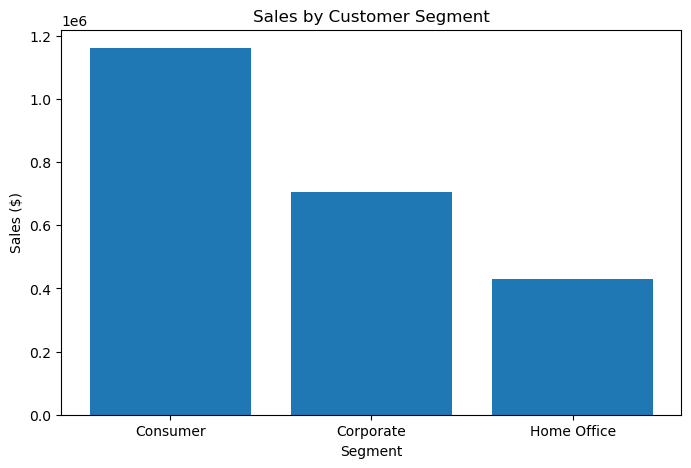

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_by_segment["segment"],
    sales_by_segment["sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")

plt.show()

# Sales Performance Summary

## Key Findings

- Technology generated the highest category sales.
- Identify the highest-performing sub-category from the analysis.
- Identify the strongest sales region.
- Identify the top-performing state.
- Identify the customer segment contributing the highest revenue.

## Business Recommendations

- Increase investment in high-performing categories and regions.
- Review pricing and promotional strategies for weaker areas.
- Focus customer acquisition efforts on high-value segments while improving engagement in lower-performing segments.

## Sales Performance Insights

### Key Findings

- Phones generated the highest sales among all sub-categories.
- The West region contributed the highest revenue.
- California was the highest-selling state.
- The Consumer segment generated the largest share of sales.

### Business Recommendations

- Increase inventory for high-demand products such as Phones.
- Replicate successful sales strategies from the West region in other regions.
- Continue investing in the California market while exploring growth opportunities in lower-performing states.
- Strengthen customer loyalty programs targeting Consumer customers.

In [55]:
# =======================
# Profit by Category
# =======================

profit_by_category = (
    df.groupby("category", as_index=False)["profit"]
    .sum()
    .sort_values(by="profit", ascending=False)
)

profit_by_category

,category,profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


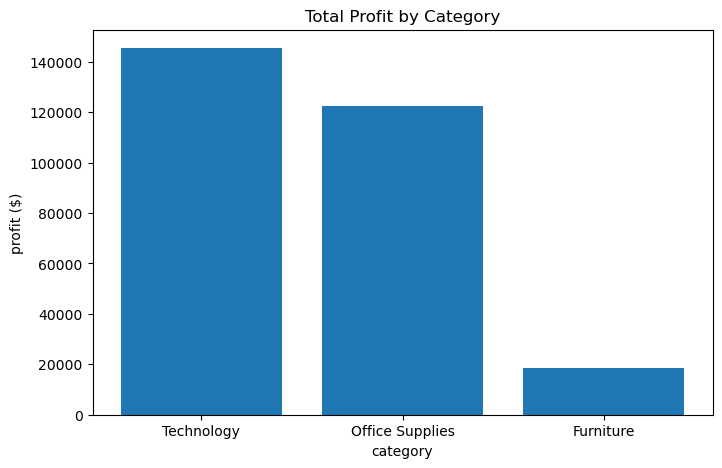

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_by_category["category"],
    profit_by_category["profit"]
)

plt.title("Total Profit by Category")
plt.xlabel("category")
plt.ylabel("profit ($)")

plt.show()

## Business Insight

Technology generated the highest total profit, making it the most profitable category.

Furniture generated the lowest profit despite strong sales, suggesting that discounting, shipping costs, or low margins may be reducing profitability.

### Recommendation

Review pricing and discount strategies for Furniture while continuing to invest in Technology products.

In [60]:
# ========================
# Profit by Sub-Category
# ========================

profit_by_subcategory = (
    df.groupby("sub_category", as_index=False)["profit"]
    .sum()
    .sort_values(by="profit", ascending=False)
)

profit_by_subcategory

,sub_category,profit
6,Copiers,55617.8249
13,Phones,44515.7306
0,Accessories,41936.6357
12,Paper,34053.5693
3,Binders,30221.7633
5,Chairs,26590.1663
14,Storage,21278.8264
1,Appliances,18138.0054
9,Furnishings,13059.1436
7,Envelopes,6964.1767


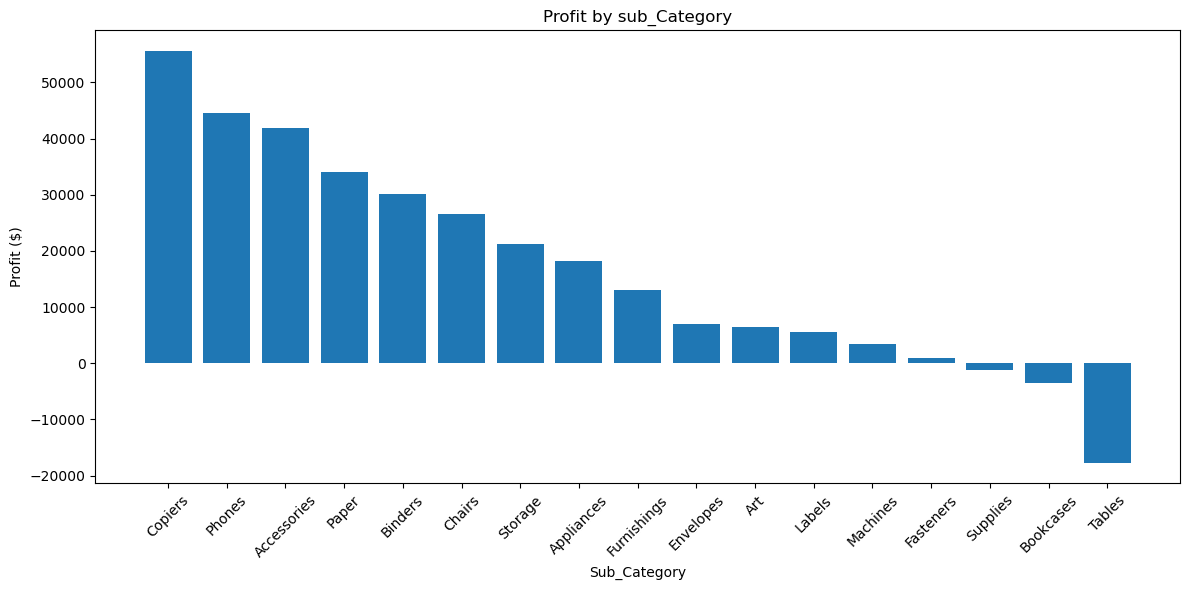

In [61]:
plt.figure(figsize=(12,6))

plt.bar(
    profit_by_subcategory["sub_category"],
    profit_by_subcategory["profit"]
)

plt.title("Profit by sub_Category")
plt.xlabel("Sub_Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

## Business Insight

Copiers generated the highest profit, indicating they are one of the company's most valuable product lines.

Tables generated the largest losses, suggesting pricing, discounting, or operational costs should be reviewed.

### Recommendation

- Increase focus on profitable products such as Copiers.
- Investigate pricing, discounts, and shipping costs for Tables before making product portfolio decisions.

In [63]:
# Correlation between Discount and Profit

correlation = df["discount"].corr(df["profit"])

print(f"Correlation between Discount and Profit: {correlation: .2f}")

Correlation between Discount and Profit: -0.22


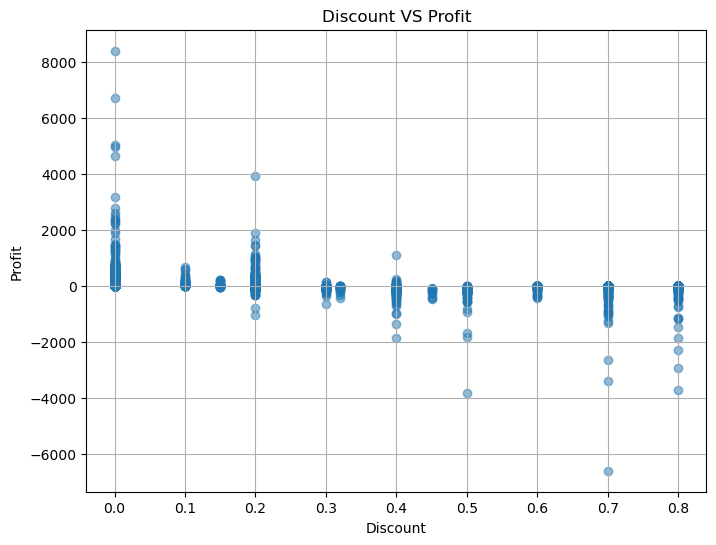

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.5
)

plt.title("Discount VS Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

## Business Insight

The correlation between **Discount** and **Profit** is **-0.22**, indicating a weak negative relationship.

Higher discounts generally reduce profitability, although other factors such as product category, cost structure, and shipping expenses also influence profit.

### Recommendation

- Review high-discount transactions.
- Optimize promotional campaigns.
- Avoid excessive discounting on low-margin products.

In [79]:
# ==============================
# Monthly Sales & Profit Trend
# ==============================

monthly_trend = (
    df.groupby(["order_year", "order_month", "order_month_name"], as_index=False)
    .agg(
        total_sales = ("sales", "sum"),
        total_profit = ("profit", "sum")
    )
)

monthly_trend.head(15)

,order_year,order_month,order_month_name,total_sales,total_profit
0,2014,1,January,28953.7060,4549.4546
1,2014,2,February,12743.1080,2654.5569
2,2014,3,March,54801.9060,92.6990
3,2014,4,April,24710.0160,4601.0714
4,2014,5,May,29639.8340,3912.2499
5,2014,6,June,29287.0306,4499.7446
6,2014,7,July,35341.2460,-1783.5425
7,2014,8,August,37854.5475,2081.2676
8,2014,9,September,66110.2238,10232.2626
9,2014,10,October,34561.9470,4075.1499


In [84]:
yearly_sales = (
    df.groupby("order_year", as_index=False)["sales"]
      .sum()
      .sort_values(by="sales", ascending=False)
)

yearly_sales

,order_year,sales
3,2017,733215.2552
2,2016,609205.5980
0,2014,484247.4981
1,2015,470532.5090


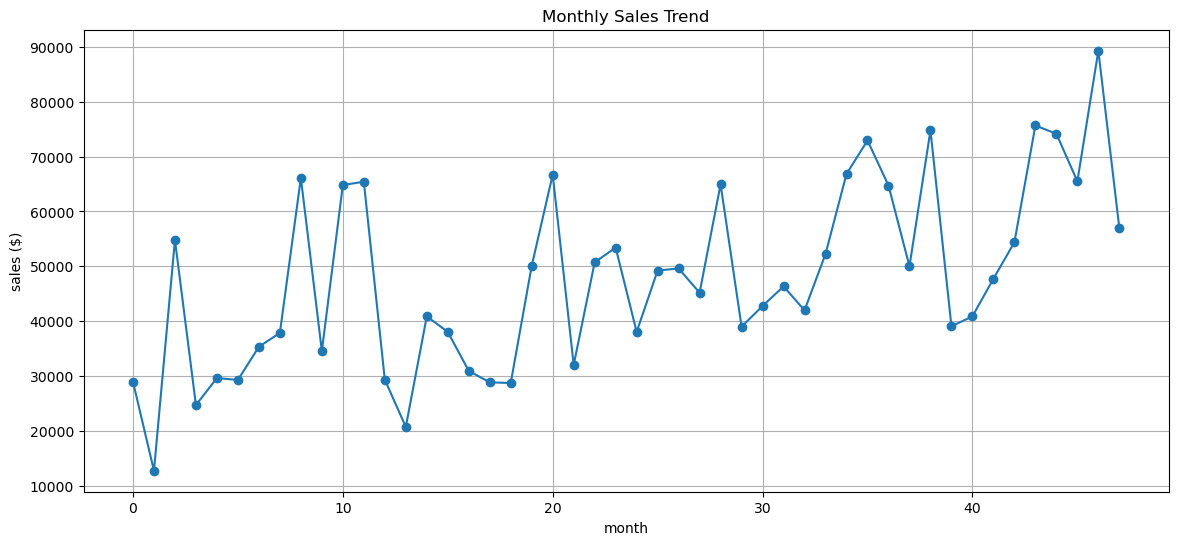

In [82]:
# Monthly Sales Trend Chart
plt.figure(figsize=(14,6))

plt.plot(
    monthly_trend["total_sales"],
    marker = 'o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("sales ($)")
plt.grid(True)
plt.show()

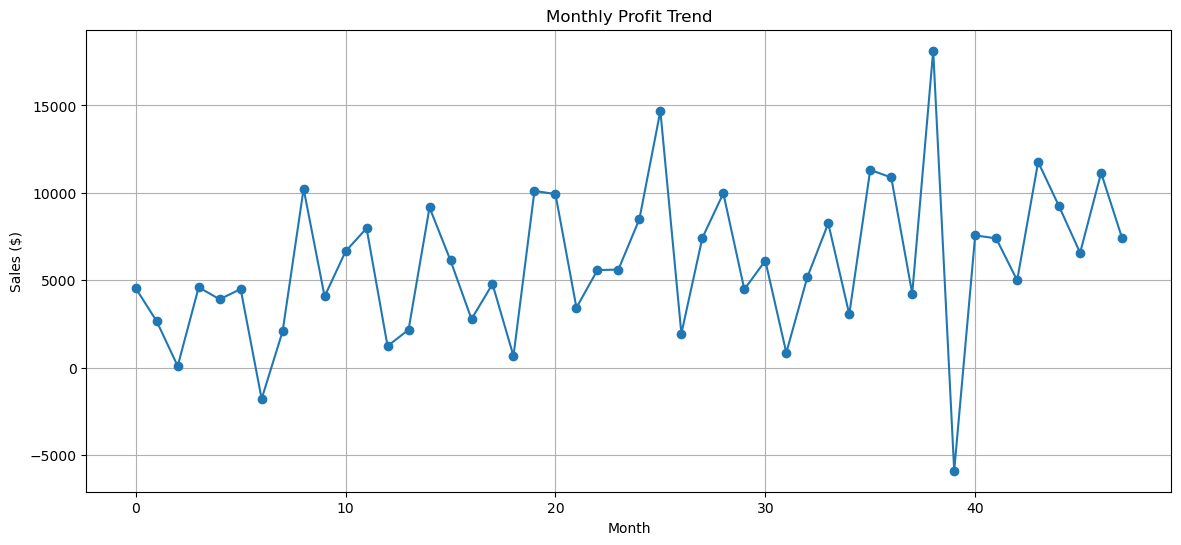

In [83]:
# Monthly Profit Trend
plt.figure(figsize=(14,6))

plt.plot(
    monthly_trend["total_profit"],
    marker= "o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

# Business Insight

Monthly sales and profit trends help identify seasonal demand and long-term growth patterns.

### Recommendation

- Increase inventory before high-sales months.
- Launch marketing campaigns ahead of seasonal peaks.
- Investigate months with unusually low profit to identify operational or pricing issues.

In [89]:
# ===========================
# Top 10 Customers by Sales
# ===========================

top_customers = (
    df.groupby(
        [
            "customer_id", 
            "customer_name"
        ],
        as_index=False
    )["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
    .head(10)
)

top_customers

,customer_id,customer_name,sales
700,SM-20320,Sean Miller,25043.050
741,TC-20980,Tamara Chand,19052.218
621,RB-19360,Raymond Buch,15117.339
730,TA-21385,Tom Ashbrook,14595.620
6,AB-10105,Adrian Barton,14473.571
434,KL-16645,Ken Lonsdale,14175.229
669,SC-20095,Sanjit Chand,14142.334
327,HL-15040,Hunter Lopez,12873.298
683,SE-20110,Sanjit Engle,12209.438
131,CC-12370,Christopher Conant,12129.072


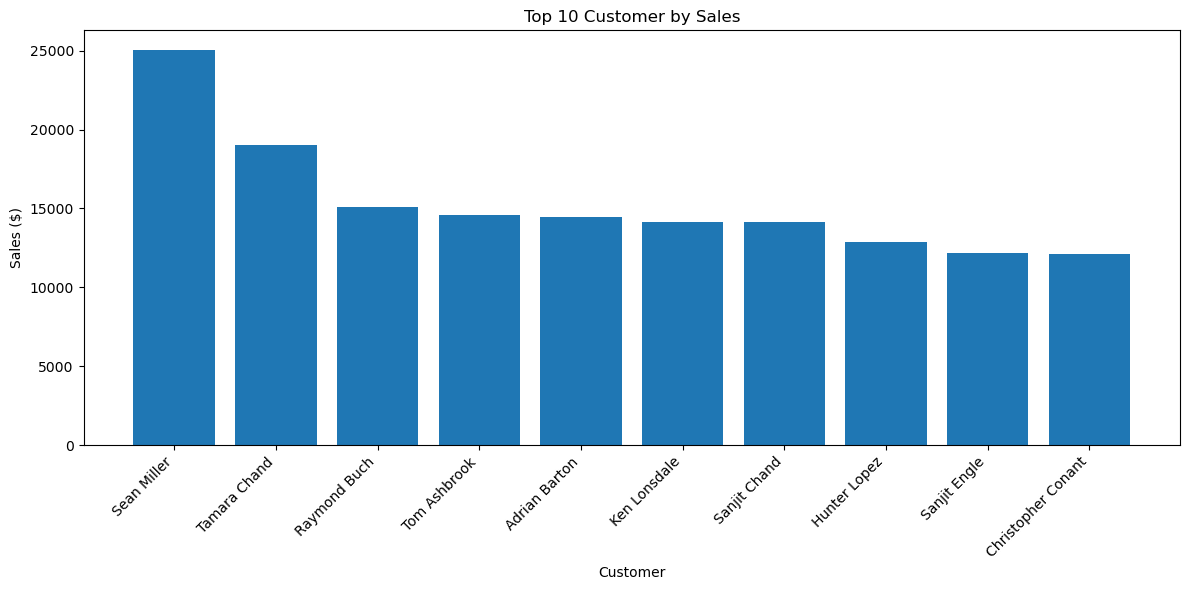

In [90]:
plt.figure(figsize=(12,6))

plt.bar(
    top_customers["customer_name"],
    top_customers["sales"]
)

plt.title("Top 10 Customer by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Business Insight

Sean Miller is the highest revenue-generating customer, contributing approximately **$25,000** in sales.

### Recommendation

- Develop loyalty programs for top customers.
- Offer personalized promotions.
- Monitor purchasing behavior to reduce churn and maximize customer lifetime value.

In [91]:
# ==========================
# Top 10 Products by Sales
# ==========================

top_products = (
    df.groupby("product_name", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
    .head(10)
)

top_products

,product_name,sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


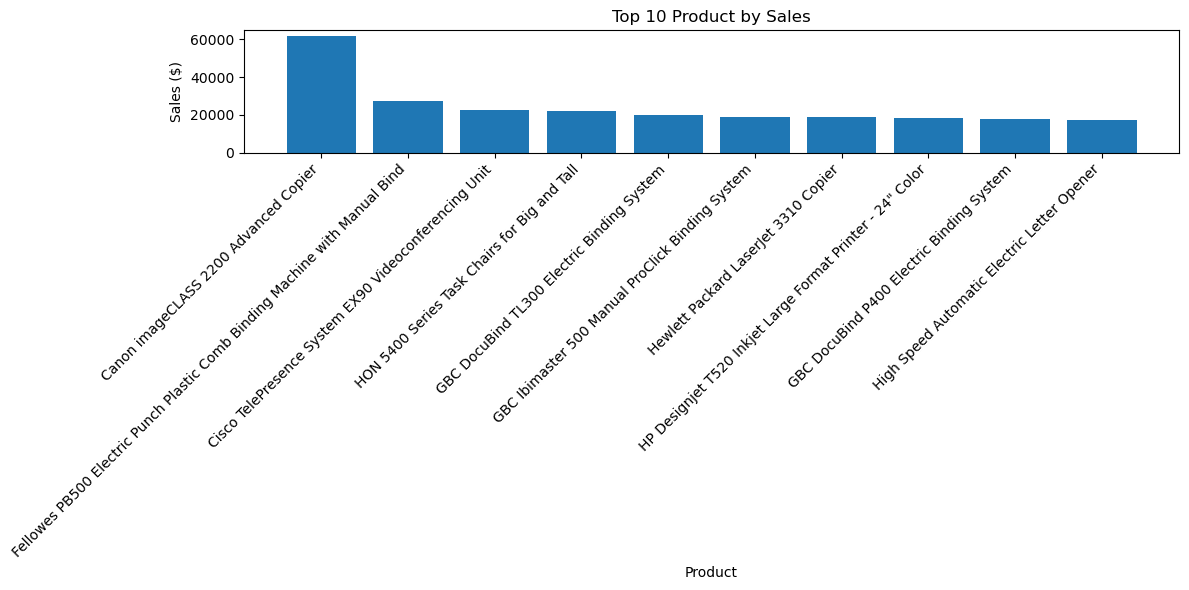

In [100]:
plt.figure(figsize=(12,6))

plt.bar(
    top_products["product_name"],
    top_products["sales"]
)

plt.title("Top 10 Product by Sales")
plt.xlabel("Product")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Business Insight

The **Canon imageCLASS 2200 Advanced Copier** generated the highest sales, contributing over **$60,000** in revenue.

### Recommendation

- Maintain sufficient inventory.
- Prioritize marketing and promotions.
- Bundle complementary products to increase revenue per customer.

In [101]:
print("=" * 50)
print("EXECUTIVE KPI SUMMARY")
print("=" * 50)

print(f"Total Sales           : ${total_sales:,.2f}")
print(f"Total Profit          : ${total_profit:,.2f}")
print(f"Total Orders          : {total_orders:,}")
print(f"Total Customers       : {total_customers:,}")
print(f"Average Order Value   : ${average_order_value:,.2f}")
print(f"Profit Margin         : {profit_margin:.2f}%")

EXECUTIVE KPI SUMMARY
Total Sales           : $2,297,200.86
Total Profit          : $286,397.02
Total Orders          : 5,009
Total Customers       : 793
Average Order Value   : $458.61
Profit Margin         : 12.47%


# Executive Business Insights

## 1. Sales Performance

- Technology generated the highest sales among all categories.
- Phones were the highest-selling sub-category.
- The West region generated the highest revenue.
- California was the top-performing state.
- Consumer customers contributed the highest sales.

### Recommendation
Increase inventory and marketing investment in Technology products and strengthen customer retention programs for the Consumer segment.

---

## 2. Profitability

- Technology generated the highest total profit.
- Furniture generated the lowest profit.
- Copiers were the most profitable sub-category.
- Tables generated the highest losses.

### Recommendation
Review pricing, supplier costs, and discount policies for Furniture and Tables.

---

## 3. Customer Analysis

- Sean Miller was the highest revenue-generating customer.

### Recommendation
Introduce loyalty programs and personalized offers for high-value customers.

---

## 4. Product Performance

- Canon imageCLASS 2200 Advanced Copier generated the highest sales.

### Recommendation
Maintain sufficient inventory and promote this product through targeted campaigns.

---

## 5. Discount Analysis

- Discount and Profit showed a weak negative correlation (-0.22).

### Recommendation
Avoid excessive discounts on low-margin products and regularly evaluate promotional campaigns.

---

## Overall Conclusion

The business is growing steadily, with Technology products, Consumer customers, and the West region driving revenue. However, profitability is negatively affected by certain Furniture products and higher discount levels. Optimizing pricing strategies while continuing investment in high-performing products and customers can improve overall profitability.